# Gingles Analysis: Precinct Scatter + Regression

**Inputs:** the GerryChain-ready shapefiles in `cleaned/gerrychain/` (MA precincts, TX VTDs).  Each row already carries 2024 presidential vote totals (`G24PREDHAR`, `G24PRERTRU`) and per-group VAP columns.

**What we compute, per precinct/VTD and per minority group:**
1. *Minority VAP %* — `group_VAP / total_VAP`
2. *Democratic vote share* — `harris / (harris + trump)`

Plotting (1) on the x-axis vs (2) on the y-axis, with a smoothed regression curve, is the heart of a *Gingles* analysis: it's the visual evidence used to argue that a minority group is politically cohesive (preconditions 2 and 3 of *Thornburg v. Gingles*).

**Outputs:**
- `cleaned/analysis/{ma,tx}_gingles_precinct.json` — scatter points
- `cleaned/analysis/{ma,tx}_gingles_regression.json` — 200-point smoothed curves

In [1]:
import json
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")

# Reuse the smoother from the modular pipeline so we get the same
# fallback chain (statsmodels LOWESS → scipy spline → linear interp).
from clean.helpers import lowess_or_spline
from clean.paths import ANALYSIS_DIR, GERRYCHAIN_DIR

print("GerryChain dir:", GERRYCHAIN_DIR)
print("Analysis dir:  ", ANALYSIS_DIR)

GerryChain dir: /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/gerrychain
Analysis dir:   /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/analysis


## 1. Load the shapefiles

These were produced upstream by `clean.ma_precincts.run()` / `clean.tx_vtds.run()` / `clean.tx_geometry.run()` / `clean.tx_asian.run()`.  We don't reproject here — Gingles only needs the attribute columns, not geometry.

In [2]:
ma = gpd.read_file(os.path.join(GERRYCHAIN_DIR, "ma_precincts.shp"))
tx = gpd.read_file(os.path.join(GERRYCHAIN_DIR, "tx_vtds.shp"))

print(f"MA: {len(ma):,} precincts")
print(f"TX: {len(tx):,} VTDs")
print("\nMA columns of interest:",
      [c for c in ma.columns if c in {"G24PREDHAR", "G24PRERTRU", "VAP", "HVAP", "BVAP", "ASIANVAP"}])
print("TX columns of interest:",
      [c for c in tx.columns if c in {"G24PREDHAR", "G24PRERTRU", "VAP", "HISPVAP", "BVAP", "ASIANVAP"}])

# Peek at the actual rows (geometry dropped for readability).
ma.drop(columns="geometry")[["NAME", "TOWN", "VAP", "HVAP", "BVAP", "ASIANVAP",
                              "G24PREDHAR", "G24PRERTRU"]].head()

MA: 2,151 precincts
TX: 8,941 VTDs

MA columns of interest: ['VAP', 'HVAP', 'BVAP', 'ASIANVAP', 'G24PREDHAR', 'G24PRERTRU']
TX columns of interest: ['VAP', 'HISPVAP', 'BVAP', 'G24PREDHAR', 'G24PRERTRU', 'ASIANVAP']


,NAME,TOWN,VAP,HVAP,BVAP,ASIANVAP,G24PREDHAR,G24PRERTRU
0,Abington Town Precinct 1,Abington,2545,33,58,36,1019,905
1,Abington Town Precinct 2,Abington,2412,40,18,30,833,882
2,Abington Town Precinct 3,Abington,2314,38,18,36,872,985
3,Abington Town Precinct 4,Abington,2482,43,68,45,978,954
4,Abington Town Precinct 5,Abington,2550,57,59,60,1012,913


In [3]:
# And the tail of TX so we see the other state too.
tx.drop(columns="geometry")[["COUNTY", "CNTYVTD", "VAP", "HISPVAP", "BVAP", "ASIANVAP",
                              "G24PREDHAR", "G24PRERTRU"]].tail()

,COUNTY,CNTYVTD,VAP,HISPVAP,BVAP,ASIANVAP,G24PREDHAR,G24PRERTRU
8936,Coryell,990412,4308.0,568.0,667.0,176,705,1152
8937,Coryell,990413,11019.0,1869.0,2969.0,58,307,1427
8938,Coryell,990414,426.0,20.0,2.0,0,20,302
8939,Coryell,990415,186.0,6.0,0.0,0,21,173
8940,Coryell,990416,4025.0,519.0,807.0,141,889,1182


## 2. Per-precinct Democratic vote share

Two-way share (Harris vs Trump) — third-party votes are dropped.  Precincts with zero presidential votes get `d_share=0` and are masked out so they don't contaminate the regression.

In [4]:
def vote_share(gdf):
    pres_d = gdf["G24PREDHAR"].values.astype(float)
    pres_r = gdf["G24PRERTRU"].values.astype(float)
    total = pres_d + pres_r
    has_votes = total > 0
    d_share = np.zeros(len(gdf))
    d_share[has_votes] = pres_d[has_votes] / total[has_votes]
    return d_share, has_votes

ma_share, ma_has_votes = vote_share(ma)
tx_share, tx_has_votes = vote_share(tx)

print(f"MA: {ma_has_votes.sum():,}/{len(ma):,} precincts have presidential votes")
print(f"    median D share among those: {np.median(ma_share[ma_has_votes]):.3f}")
print(f"TX: {tx_has_votes.sum():,}/{len(tx):,} VTDs have presidential votes")
print(f"    median D share among those: {np.median(tx_share[tx_has_votes]):.3f}")

MA: 2,150/2,151 precincts have presidential votes
    median D share among those: 0.629
TX: 8,747/8,941 VTDs have presidential votes
    median D share among those: 0.433


## 3. Build the scatter data

For each (state, group) pair we emit one record per *valid* precinct — valid meaning it has both presidential votes and non-zero VAP.  Each record is what a chart library can plot directly.

In [5]:
def scatter_for_group(gdf, vap_col, d_share, has_votes, names, ids):
    total_vap = gdf["VAP"].values.astype(float)
    total_pop = gdf["TOTPOP"].values.astype(float)
    has_vap = total_vap > 0

    minority_vap = gdf[vap_col].values.astype(float)
    minority_pct = np.zeros(len(gdf))
    minority_pct[has_vap] = minority_vap[has_vap] / total_vap[has_vap]

    points = []
    for i in np.where(has_votes & has_vap)[0]:
        points.append({
            "precinct_id": ids[i],
            "name": str(names[i]),
            "total_pop": int(total_pop[i]),
            "minority_pop": int(minority_vap[i]),
            "minority_vap_pct": round(float(minority_pct[i]), 4),
            "d_vote_share": round(float(d_share[i]), 4),
        })
    return points


def build_state_scatter(gdf, group_cols, name_col, id_col, d_share, has_votes):
    names = gdf[name_col].values
    ids = gdf[id_col].astype(str).values
    out = {}
    for group_name, vap_col in group_cols.items():
        if vap_col not in gdf.columns:
            print(f"  skipping {group_name}: column {vap_col} missing")
            continue
        out[group_name] = scatter_for_group(gdf, vap_col, d_share, has_votes, names, ids)
    return out


# MA: hispanic + black + asian (always feasible in MA)
MA_GROUPS = {"hispanic": "HVAP", "black": "BVAP", "asian": "ASIANVAP"}
ma_data = build_state_scatter(ma, MA_GROUPS, "NAME", "NAME", ma_share, ma_has_votes)
for g, pts in ma_data.items():
    print(f"MA {g}: {len(pts):,} precincts")

# TX: hispanic + black always; asian only if step 4 enrichment populated it
TX_GROUPS = {"hispanic": "HISPVAP", "black": "BVAP"}
if "ASIANVAP" in tx.columns and tx["ASIANVAP"].sum() > 0:
    TX_GROUPS["asian"] = "ASIANVAP"
tx_data = build_state_scatter(tx, TX_GROUPS, "COUNTY", "CNTYVTD", tx_share, tx_has_votes)
for g, pts in tx_data.items():
    print(f"TX {g}: {len(pts):,} VTDs")

# Peek at the first 3 MA hispanic records and the last 3 TX black records to see the shape.
print("\nFirst 3 MA hispanic records:")
for r in ma_data["hispanic"][:3]:
    print(" ", r)

MA hispanic: 2,150 precincts
MA black: 2,150 precincts
MA asian: 2,150 precincts


TX hispanic: 8,584 VTDs
TX black: 8,584 VTDs
TX asian: 8,584 VTDs

First 3 MA hispanic records:
  {'precinct_id': 'Abington Town Precinct 1', 'name': 'Abington Town Precinct 1', 'total_pop': 3295, 'minority_pop': 33, 'minority_vap_pct': 0.013, 'd_vote_share': 0.5296}
  {'precinct_id': 'Abington Town Precinct 2', 'name': 'Abington Town Precinct 2', 'total_pop': 3121, 'minority_pop': 40, 'minority_vap_pct': 0.0166, 'd_vote_share': 0.4857}
  {'precinct_id': 'Abington Town Precinct 3', 'name': 'Abington Town Precinct 3', 'total_pop': 3068, 'minority_pop': 38, 'minority_vap_pct': 0.0164, 'd_vote_share': 0.4696}


## 4. Persist the scatter data


In [6]:
os.makedirs(ANALYSIS_DIR, exist_ok=True)

for state, payload in [("ma", ma_data), ("tx", tx_data)]:
    out = os.path.join(ANALYSIS_DIR, f"{state}_gingles_precinct.json")
    with open(out, "w") as f:
        json.dump(payload, f)
    print(f"wrote {out} ({os.path.getsize(out):,} bytes)")

wrote /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/analysis/ma_gingles_precinct.json (1,151,835 bytes)


wrote /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/analysis/tx_gingles_precinct.json (3,525,614 bytes)


## 5. NON-LIN-Regression curves

`lowess_or_spline` from `clean.helpers` returns 200 evenly-spaced `(x, y)` points clipped to `[0, 1]`.  Statsmodels LOWESS is preferred; if not installed it falls back to a scipy `UnivariateSpline`, then to plain linear interpolation.

In [7]:
def fit_state_curves(scatter_data, label):
    out = {}
    for group_name, points in scatter_data.items():
        if len(points) < 20:
            print(f"  {label} {group_name}: only {len(points)} points, skipping")
            continue
        x = np.array([p["minority_vap_pct"] for p in points])
        y = np.array([p["d_vote_share"] for p in points])
        x_fit, y_fit = lowess_or_spline(x, y, n_points=200)
        out[group_name] = [
            {"x": round(float(xi), 4), "y": round(float(yi), 4)}
            for xi, yi in zip(x_fit, y_fit)
        ]
        print(f"  {label} {group_name}: {len(out[group_name])} curve points")
    return out

ma_regression = fit_state_curves(ma_data, "MA")
tx_regression = fit_state_curves(tx_data, "TX")

for state, payload in [("ma", ma_regression), ("tx", tx_regression)]:
    out = os.path.join(ANALYSIS_DIR, f"{state}_gingles_regression.json")
    with open(out, "w") as f:
        json.dump(payload, f)
    print(f"wrote {out} ({os.path.getsize(out):,} bytes)")

# Head + tail of the MA hispanic curve — see how D-share rises across the x-grid.
print("\nMA hispanic curve — first 3 points:")
for p in ma_regression["hispanic"][:3]:
    print(" ", p)
print("MA hispanic curve — last 3 points:")
for p in ma_regression["hispanic"][-3:]:
    print(" ", p)

  MA hispanic: 200 curve points
  MA black: 200 curve points
  MA asian: 200 curve points
  TX hispanic: 200 curve points
  TX black: 200 curve points
  TX asian: 200 curve points
wrote /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/analysis/ma_gingles_regression.json (16,701 bytes)
wrote /Users/j/Desktop/2026 SPRING/CSE 416/server/database/data/cleaned/analysis/tx_gingles_regression.json (17,012 bytes)

MA hispanic curve — first 3 points:
  {'x': 0.0, 'y': 0.5901}
  {'x': 0.0046, 'y': 0.5964}
  {'x': 0.0092, 'y': 0.6024}
MA hispanic curve — last 3 points:
  {'x': 0.9018, 'y': 0.7099}
  {'x': 0.9064, 'y': 0.715}
  {'x': 0.911, 'y': 0.7202}


## 6. Visualize

Quick sanity check — scatter + fitted curve for each (state, group).  An upward slope means precincts with higher minority VAP % vote more Democratic on average, which is the cohesion signal Gingles is looking for.

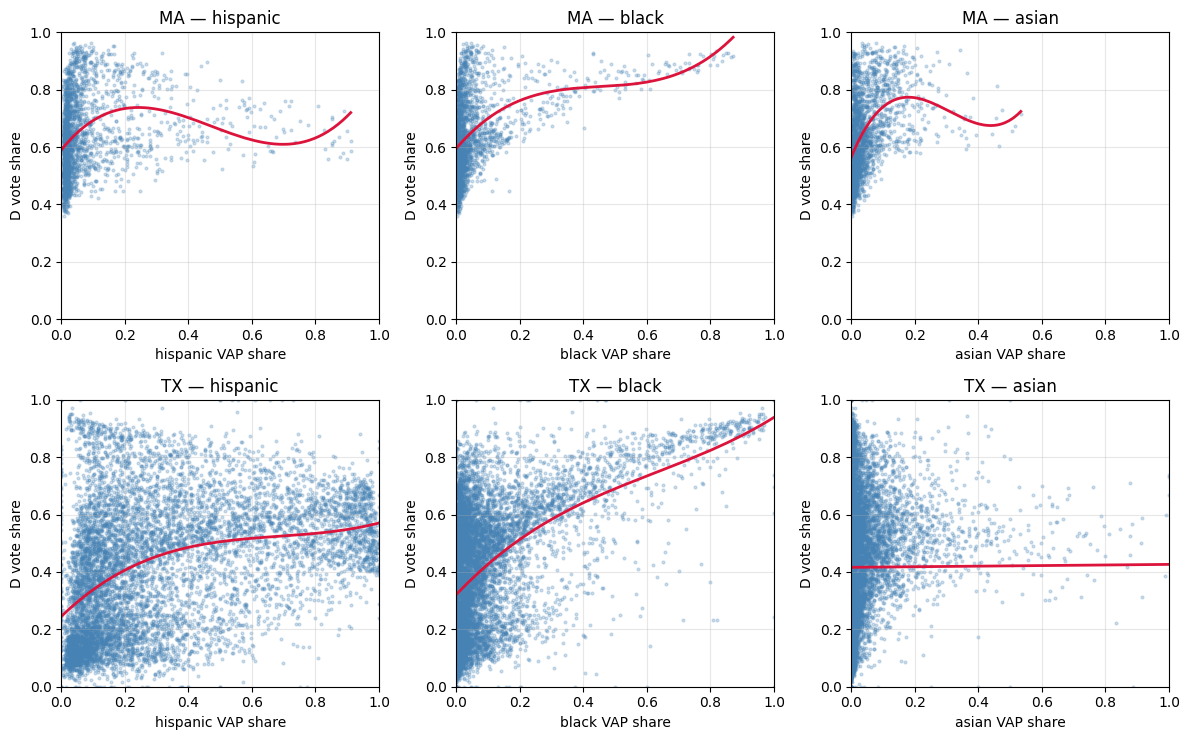

In [8]:
def plot_state(ax_row, scatter, regression, state_label):
    groups = list(scatter.keys())
    for ax, group in zip(ax_row, groups):
        pts = scatter[group]
        x = [p["minority_vap_pct"] for p in pts]
        y = [p["d_vote_share"] for p in pts]
        ax.scatter(x, y, s=4, alpha=0.25, color="steelblue")
        if group in regression:
            curve = regression[group]
            ax.plot([c["x"] for c in curve], [c["y"] for c in curve],
                    color="crimson", linewidth=2)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel(f"{group} VAP share")
        ax.set_ylabel("D vote share")
        ax.set_title(f"{state_label} — {group}")
        ax.grid(alpha=0.3)

n_cols = max(len(ma_data), len(tx_data))
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7.5))
if n_cols == 1:
    axes = np.array([[axes[0]], [axes[1]]])
plot_state(axes[0], ma_data, ma_regression, "MA")
plot_state(axes[1], tx_data, tx_regression, "TX")
# Hide any unused axes (e.g. TX missing a group)
for row, scat in zip(axes, [ma_data, tx_data]):
    for ax in row[len(scat):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()